# Week 8 - Minimax e Alpha-Beta Pruning

Neste notebook vamos estudar o algoritmo **minimax** e, em seguida, a sua otimização com **alpha-beta pruning**.

O que faremos:
- usamos uma estrutura de grafo simples, em formato de dicionário;
- visualizamos a árvore de jogo;
- construímos o raciocínio passo a passo;
- implementamos o algoritmo.

## Objetivos da aula

Ao final deste notebook, você deve conseguir:

1. representar uma árvore de jogo com dicionários em Python;
2. entender o papel de nós MAX e nós MIN;
3. implementar o algoritmo minimax com base no pseudocódigo;
4. identificar a melhor jogada a partir da raiz;
5. entender como o alpha-beta pruning evita explorar ramos desnecessários.


## Imports

Vamos usar `networkx` e `matplotlib` apenas para visualização.


In [13]:
# se não tiver instalado
# !pip install networkx matplotlib


In [14]:
import math
import matplotlib.pyplot as plt
import networkx as nx


# Parte 1 - Minimax

## Ideia geral

O algoritmo minimax é muito usado em jogos de tabuleiro, árvores de decisão e problemas de busca adversarial.

A lógica é a seguinte:
- em um nível, o jogador **MAX** tenta **maximizar** a pontuação;
- no nível seguinte, o jogador **MIN** tenta **minimizar** a pontuação;
- isso continua até chegar aos nós folhas;
- cada folha já possui uma **avaliação estática** do estado.

Depois, esses valores sobem pela árvore:
- nós MAX escolhem o maior valor entre seus filhos;
- nós MIN escolhem o menor valor entre seus filhos.


## Pseudocódigo de referência

Vamos seguir a ideia clássica do pseudocódigo:

```text
function minimax(position, depth, maximizingPlayer)
    if depth == 0 or game over in position
        return static evaluation of position

    if maximizingPlayer
        maxEval = -infinity
        for each child of position
            eval = minimax(child, depth - 1, false)
            maxEval = max(maxEval, eval)
        return maxEval
    else
        minEval = +infinity
        for each child of position
            eval = minimax(child, depth - 1, true)
            minEval = min(minEval, eval)
        return minEval
```

Neste notebook, `position` será o nó atual da nossa árvore.


## Como vamos representar a árvore

Vamos usar um dicionário com listas de adjacência.

- Cada chave representa um nó.
- Se o valor associado for uma lista, aquele nó possui filhos.
- Se o valor associado for um número, então o nó é folha e esse número é o seu score.

Ou seja:
- `arvore['A'] = ['B', 'C']` quer dizer que `A` aponta para `B` e `C`;
- se `E` é folha, então `arvore['E'] = 3`.


In [15]:
arvore_minimax = {
    'A': ['B', 'C', 'D'],
    'B': ['E', 'F'],
    'C': ['G', 'H'],
    'D': ['I', 'J'],
    'E': 3,
    'F': 5,
    'G': 2,
    'H': 9,
    'I': 12,
    'J': 5
}

raiz_minimax = 'A'
profundidade_minimax = 2


## Funções prontas para visualização

As funções abaixo já estão prontas para você usar.

Elas servem para:
- montar a árvore com `networkx`;
- desenhar a árvore com os scores das folhas;
- destacar valores calculados pelo minimax;
- mostrar um histórico textual da execução.

A ideia é que você foque na implementação do algoritmo, e use essas visualizações para acompanhar o raciocínio.


In [16]:
def eh_folha(arvore, no):
    return not isinstance(arvore[no], list)


def filhos_de(arvore, no):
    return [] if eh_folha(arvore, no) else arvore[no]


def hierarchy_pos(G, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """Cria posições hierárquicas para desenhar uma árvore."""
    pos = {}

    def _dfs(node, left, right, depth):
        pos[node] = ((left + right) / 2, -depth * vert_gap + vert_loc)
        children = list(G.successors(node))
        if not children:
            return
        step = (right - left) / len(children)
        for i, child in enumerate(children):
            child_left = left + i * step
            child_right = left + (i + 1) * step
            _dfs(child, child_left, child_right, depth + 1)

    _dfs(root, 0, width, 0)
    return pos


def construir_grafo(arvore):
    G = nx.DiGraph()
    for origem, valor in arvore.items():
        G.add_node(origem)
        if isinstance(valor, list):
            for filho in valor:
                G.add_edge(origem, filho)
    return G


def coletar_subarvore(arvore, no):
    nos = {no}
    if eh_folha(arvore, no):
        return nos
    for filho in filhos_de(arvore, no):
        nos.update(coletar_subarvore(arvore, filho))
    return nos


def desenhar_arvore_jogo(arvore, raiz, valores=None, podados=None, destaque=None, titulo=''):
    valores = valores or {}
    podados = set(podados or [])
    destaque = set(destaque or [])

    G = construir_grafo(arvore)
    pos = hierarchy_pos(G, raiz)

    cores = []
    labels = {}

    for no in G.nodes():
        if no in podados:
            cores.append('lightgray')
        elif no in destaque:
            cores.append('gold')
        elif eh_folha(arvore, no):
            cores.append('lightsalmon')
        else:
            cores.append('skyblue')

        if eh_folha(arvore, no):
            labels[no] = f"{no}\nscore={arvore[no]}"
        elif no in valores:
            labels[no] = f"{no}\nv={valores[no]}"
        else:
            labels[no] = no

    plt.figure(figsize=(11, 6))
    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_color=cores,
        edge_color='gray',
        node_size=2400,
        font_size=10,
        font_weight='bold',
        arrows=False
    )
    plt.title(titulo)
    plt.axis('off')
    plt.show()


def mostrar_historico_execucao(historico_execucao, titulo='Histórico da execução'):
    print(titulo)
    print('-' * len(titulo))
    for passo in historico_execucao:
        print(passo)


def calcular_valores_para_visualizacao(arvore, raiz, profundidade, maximizando=True):
    valores = {}

    def _percorrer(no, profundidade_atual, jogador_max):
        valor = minimax(arvore, no, profundidade_atual, jogador_max)
        valores[no] = valor
        if eh_folha(arvore, no) or profundidade_atual == 0:
            return
        for filho in filhos_de(arvore, no):
            _percorrer(filho, profundidade_atual - 1, not jogador_max)

    _percorrer(raiz, profundidade, maximizando)
    return valores


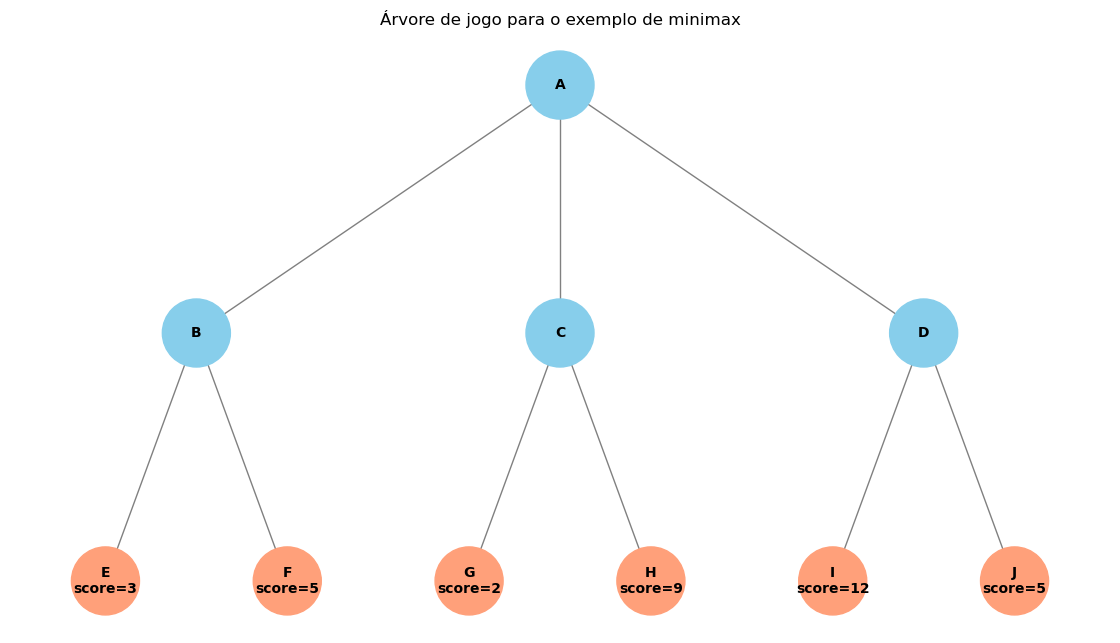

In [17]:
desenhar_arvore_jogo(
    arvore_minimax,
    raiz_minimax,
    titulo='Árvore de jogo para o exemplo de minimax'
)


## Leitura manual da árvore

Antes de programar, vale raciocinar manualmente.

- `A` é um nó **MAX**.
- `B`, `C` e `D` são nós **MIN**.
- `E`, `F`, `G`, `H`, `I` e `J` são folhas com score.

Se cada nó MIN escolhe o menor entre seus filhos:
- `B` devolve `min(3, 5)`;
- `C` devolve `min(2, 9)`;
- `D` devolve `min(12, 5)`.

Depois, `A` escolhe o maior entre esses resultados.


## Exercício 1 - Implementando o minimax

Complete a função abaixo seguindo o pseudocódigo.

Dicas:
1. o caso base acontece quando a profundidade chega a `0` ou quando o nó é folha;
2. em nó MAX, começamos com `-infinito`;
3. em nó MIN, começamos com `+infinito`;
4. use a chamada recursiva para visitar os filhos;
5. registre os valores em `valores` para podermos visualizar depois.


In [18]:
def minimax(arvore, no, profundidade, maximizando, historico_execucao=None):
    """
    Calcula o valor minimax do nó atual.

    Parâmetros:
    - arvore: dicionário da árvore de jogo.
    - no: nó atual.
    - profundidade: profundidade restante da busca.
    - maximizando: True para nó MAX, False para nó MIN.
    - historico_execucao: lista para guardar mensagens da execução.

    Retorno:
    - valor minimax do nó atual.
    """
    if historico_execucao is None:
        historico_execucao = []

    if profundidade == 0 or eh_folha(arvore, no):
        valor = arvore[no]
        historico_execucao.append(f'Folha {no}: retorna score {valor}')
        return valor

    if maximizando:
        melhor_valor = -math.inf
        historico_execucao.append(f'No MAX {no}: avaliando filhos {filhos_de(arvore, no)}')

        for filho in filhos_de(arvore, no):
            valor_filho = minimax(arvore, filho, profundidade - 1, False, historico_execucao)
            melhor_valor = max(melhor_valor, valor_filho)
            historico_execucao.append(f'No MAX {no}: filho {filho} devolveu {valor_filho}; melhor ate agora = {melhor_valor}')

        return melhor_valor

    else:
        melhor_valor = math.inf
        historico_execucao.append(f'No MIN {no}: avaliando filhos {filhos_de(arvore, no)}')

        for filho in filhos_de(arvore, no):
            valor_filho = minimax(arvore, filho, profundidade - 1, True, historico_execucao)
            melhor_valor = min(melhor_valor, valor_filho)
            historico_execucao.append(f'No MIN {no}: filho {filho} devolveu {valor_filho}; melhor ate agora = {melhor_valor}')

        return melhor_valor


## Exercício 2 - Executando o minimax

Depois de implementar a função, rode a célula abaixo para:
- calcular o valor da raiz;
- observar o histórico de execução;
- visualizar os valores propagados na árvore.


Valor minimax da raiz: 5
Histórico de execução do minimax
--------------------------------
No MAX A: avaliando filhos ['B', 'C', 'D']
No MIN B: avaliando filhos ['E', 'F']
Folha E: retorna score 3
No MIN B: filho E devolveu 3; melhor ate agora = 3
Folha F: retorna score 5
No MIN B: filho F devolveu 5; melhor ate agora = 3
No MAX A: filho B devolveu 3; melhor ate agora = 3
No MIN C: avaliando filhos ['G', 'H']
Folha G: retorna score 2
No MIN C: filho G devolveu 2; melhor ate agora = 2
Folha H: retorna score 9
No MIN C: filho H devolveu 9; melhor ate agora = 2
No MAX A: filho C devolveu 2; melhor ate agora = 3
No MIN D: avaliando filhos ['I', 'J']
Folha I: retorna score 12
No MIN D: filho I devolveu 12; melhor ate agora = 12
Folha J: retorna score 5
No MIN D: filho J devolveu 5; melhor ate agora = 5
No MAX A: filho D devolveu 5; melhor ate agora = 5


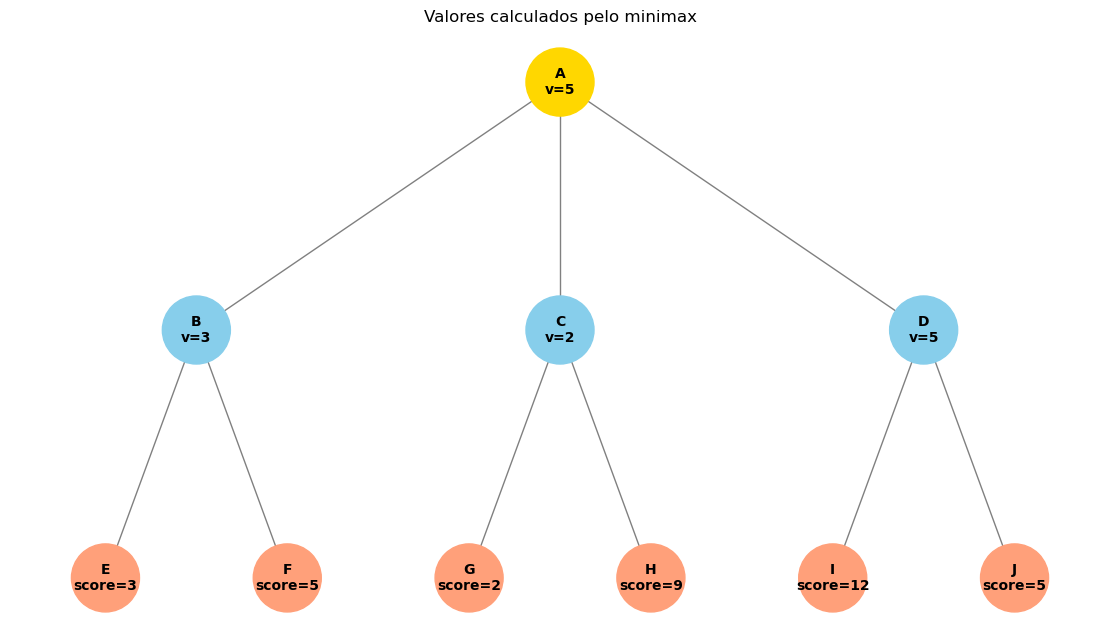

In [19]:
historico_execucao_minimax = []

valor_raiz = minimax(
    arvore_minimax,
    raiz_minimax,
    profundidade_minimax,
    True,
    historico_execucao_minimax
)

valores_minimax = calcular_valores_para_visualizacao(
    arvore_minimax,
    raiz_minimax,
    profundidade_minimax,
    True
)

print('Valor minimax da raiz:', valor_raiz)
mostrar_historico_execucao(historico_execucao_minimax, titulo='Histórico de execução do minimax')
desenhar_arvore_jogo(
    arvore_minimax,
    raiz_minimax,
    valores=valores_minimax,
    destaque=[raiz_minimax],
    titulo='Valores calculados pelo minimax'
)


## Exercício 3 - Descobrindo a melhor jogada na raiz

Agora vamos transformar o valor minimax em decisão.

A ideia é simples:
- avaliar cada filho da raiz;
- comparar os valores retornados;
- escolher o filho com maior valor, já que a raiz é um nó MAX.


In [20]:
def melhor_jogada_raiz(arvore, raiz, profundidade):
    """
    Retorna a melhor jogada a partir da raiz e o valor associado.
    """
    melhor_filho = None
    melhor_valor = -math.inf

    for filho in filhos_de(arvore, raiz):
        valor = minimax(arvore, filho, profundidade - 1, False)
        if valor > melhor_valor:
            melhor_valor = valor
            melhor_filho = filho

    return melhor_filho, melhor_valor


melhor_filho, melhor_valor = melhor_jogada_raiz(
    arvore_minimax,
    raiz_minimax,
    profundidade_minimax
)
print('Melhor jogada saindo da raiz:', melhor_filho)
print('Valor associado:', melhor_valor)


Melhor jogada saindo da raiz: D
Valor associado: 5


# Parte 2 - Alpha-Beta Pruning

O alpha-beta pruning é uma otimização do minimax.

Ele não muda a resposta final do algoritmo. O que muda é a eficiência.

A ideia é podar ramos que já sabemos que **não podem influenciar a decisão final**.

Usamos dois limites:
- `alpha`: melhor valor que MAX já conseguiu garantir;
- `beta`: melhor valor que MIN já conseguiu garantir.

Quando acontece `alpha >= beta`, podemos interromper a exploração daquele ramo.


## Nova árvore para observar a poda

Nesta segunda parte vamos usar uma árvore um pouco maior para que a poda fique visível.

Continuamos com a mesma estrutura de grafo:
- dicionário de adjacência para os nós internos;
- números diretamente associados aos nós folhas.


In [21]:
arvore_poda = {
    'A': ['B', 'C', 'D'],
    'B': ['E', 'F'],
    'C': ['G', 'H'],
    'D': ['I', 'J'],
    'E': ['K', 'L'],
    'F': ['M', 'N'],
    'G': ['O', 'P'],
    'H': ['Q', 'R'],
    'I': ['S', 'T'],
    'J': ['U', 'V'],
    'K': 3, 'L': 5,
    'M': 6, 'N': 9,
    'O': 1, 'P': 2,
    'Q': 0, 'R': -1,
    'S': 7, 'T': 4,
    'U': 8, 'V': 4
}

raiz_poda = 'A'
profundidade_poda = 3


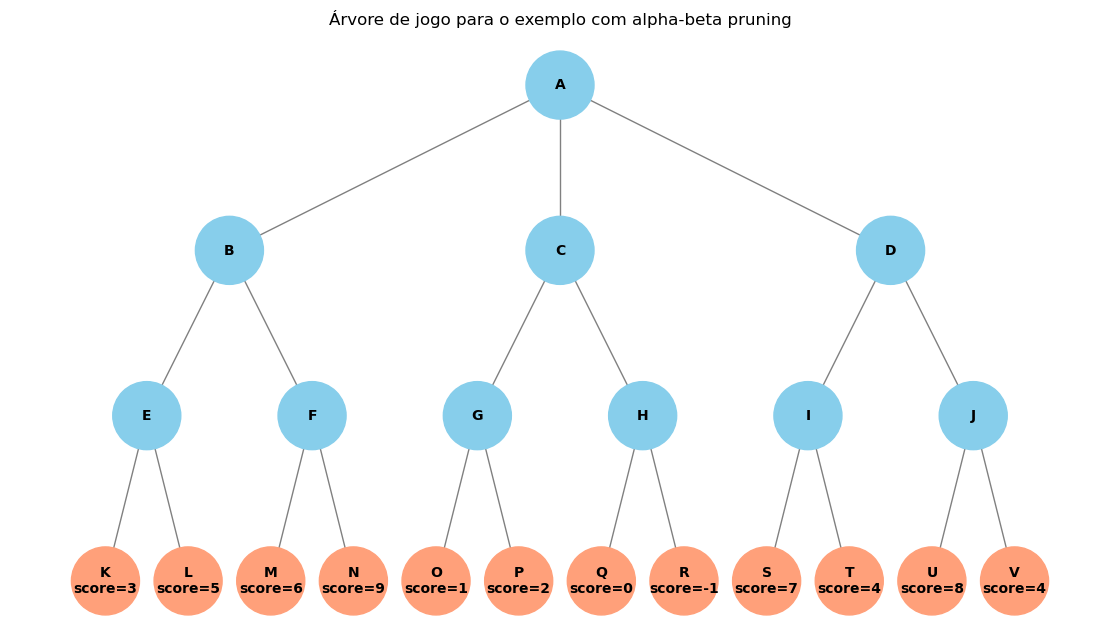

In [22]:
desenhar_arvore_jogo(
    arvore_poda,
    raiz_poda,
    titulo='Árvore de jogo para o exemplo com alpha-beta pruning'
)


## Exercício 4 - Implementando o alpha-beta pruning

Agora vamos adaptar o minimax para carregar `alpha` e `beta`.

O raciocínio é:
1. calcular os valores como no minimax normal;
2. atualizar `alpha` quando estamos em um nó MAX;
3. atualizar `beta` quando estamos em um nó MIN;
4. interromper a exploração quando `alpha >= beta`.

Também vamos registrar os nós podados em `podados`, para visualização.


In [23]:
def minimax_alpha_beta(
    arvore,
    no,
    profundidade,
    alpha,
    beta,
    maximizando,
    historico_execucao=None,
    podados=None
):
    """
    Versão do minimax com alpha-beta pruning.

    Retorna o valor minimax do nó atual e registra onde houve poda.
    """
    if historico_execucao is None:
        historico_execucao = []
    if podados is None:
        podados = set()

    if profundidade == 0 or eh_folha(arvore, no):
        valor = arvore[no]
        historico_execucao.append(f'Folha {no}: retorna score {valor}')
        return valor

    if maximizando:
        melhor_valor = -math.inf
        historico_execucao.append(f'No MAX {no}: alpha={alpha}, beta={beta}, filhos={filhos_de(arvore, no)}')

        for indice, filho in enumerate(filhos_de(arvore, no)):
            valor_filho = minimax_alpha_beta(
                arvore, filho, profundidade - 1, alpha, beta, False, historico_execucao, podados
            )
            melhor_valor = max(melhor_valor, valor_filho)
            alpha = max(alpha, melhor_valor)
            historico_execucao.append(
                f'No MAX {no}: filho {filho} devolveu {valor_filho}; melhor={melhor_valor}; alpha={alpha}; beta={beta}'
            )

            if alpha >= beta:
                restantes = filhos_de(arvore, no)[indice + 1:]
                podados_agora = set()
                for restante in restantes:
                    podados_agora.update(coletar_subarvore(arvore, restante))
                podados.update(podados_agora)
                historico_execucao.append(f'Poda em {no}: alpha ({alpha}) >= beta ({beta}); podados: {sorted(podados_agora)}')
                break

        return melhor_valor

    else:
        melhor_valor = math.inf
        historico_execucao.append(f'No MIN {no}: alpha={alpha}, beta={beta}, filhos={filhos_de(arvore, no)}')

        for indice, filho in enumerate(filhos_de(arvore, no)):
            valor_filho = minimax_alpha_beta(
                arvore, filho, profundidade - 1, alpha, beta, True, historico_execucao, podados
            )
            melhor_valor = min(melhor_valor, valor_filho)
            beta = min(beta, melhor_valor)
            historico_execucao.append(
                f'No MIN {no}: filho {filho} devolveu {valor_filho}; melhor={melhor_valor}; alpha={alpha}; beta={beta}'
            )

            if alpha >= beta:
                restantes = filhos_de(arvore, no)[indice + 1:]
                podados_agora = set()
                for restante in restantes:
                    podados_agora.update(coletar_subarvore(arvore, restante))
                podados.update(podados_agora)
                historico_execucao.append(f'Poda em {no}: alpha ({alpha}) >= beta ({beta}); podados: {sorted(podados_agora)}')
                break

        return melhor_valor


## Exercício 5 - Executando a poda

Quando a função estiver pronta, rode a célula abaixo para observar:
- o valor final da raiz;
- o histórico de execução com atualizações de `alpha` e `beta`;
- os nós podados destacados em cinza.


Valor da raiz com alpha-beta pruning: 7
Nós podados: ['H', 'N', 'Q', 'R', 'V']
Histórico de execução do alpha-beta pruning
-------------------------------------------
No MAX A: alpha=-inf, beta=inf, filhos=['B', 'C', 'D']
No MIN B: alpha=-inf, beta=inf, filhos=['E', 'F']
No MAX E: alpha=-inf, beta=inf, filhos=['K', 'L']
Folha K: retorna score 3
No MAX E: filho K devolveu 3; melhor=3; alpha=3; beta=inf
Folha L: retorna score 5
No MAX E: filho L devolveu 5; melhor=5; alpha=5; beta=inf
No MIN B: filho E devolveu 5; melhor=5; alpha=-inf; beta=5
No MAX F: alpha=-inf, beta=5, filhos=['M', 'N']
Folha M: retorna score 6
No MAX F: filho M devolveu 6; melhor=6; alpha=6; beta=5
Poda em F: alpha (6) >= beta (5); podados: ['N']
No MIN B: filho F devolveu 6; melhor=5; alpha=-inf; beta=5
No MAX A: filho B devolveu 5; melhor=5; alpha=5; beta=inf
No MIN C: alpha=5, beta=inf, filhos=['G', 'H']
No MAX G: alpha=5, beta=inf, filhos=['O', 'P']
Folha O: retorna score 1
No MAX G: filho O devolveu 1; melhor=1;

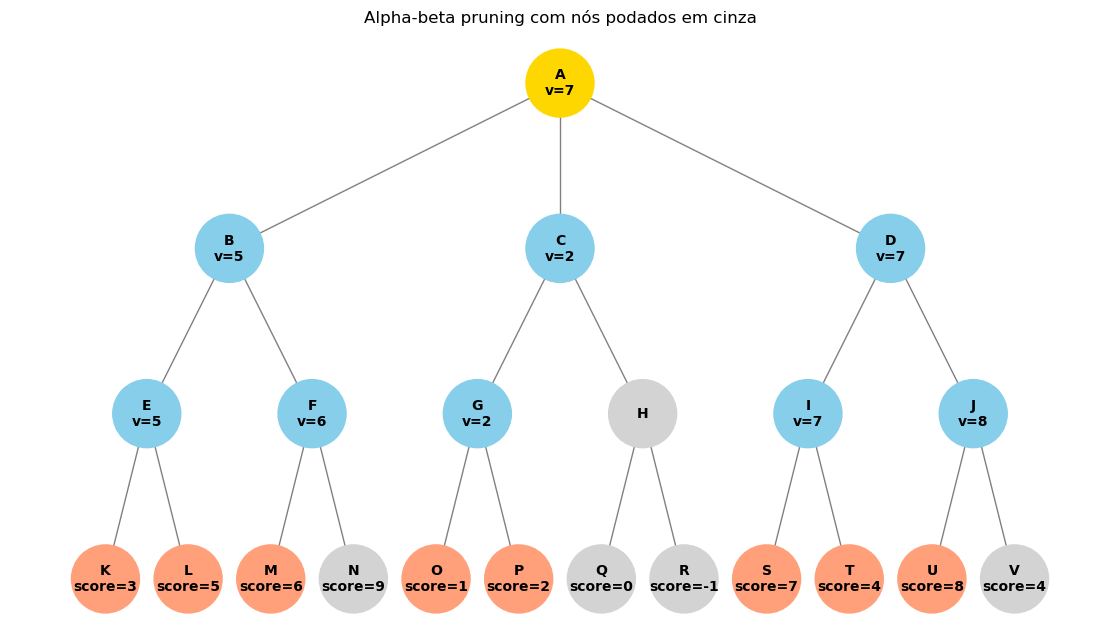

In [24]:
historico_execucao_poda = []
podados = set()

valor_raiz_poda = minimax_alpha_beta(
    arvore_poda,
    raiz_poda,
    profundidade_poda,
    -math.inf,
    math.inf,
    True,
    historico_execucao_poda,
    podados
)

valores_poda = calcular_valores_para_visualizacao(
    arvore_poda,
    raiz_poda,
    profundidade_poda,
    True
)
for no in list(valores_poda):
    if no in podados and not eh_folha(arvore_poda, no):
        del valores_poda[no]

print('Valor da raiz com alpha-beta pruning:', valor_raiz_poda)
print('Nós podados:', sorted(podados))
mostrar_historico_execucao(historico_execucao_poda, titulo='Histórico de execução do alpha-beta pruning')
desenhar_arvore_jogo(
    arvore_poda,
    raiz_poda,
    valores=valores_poda,
    podados=podados,
    destaque=[raiz_poda],
    titulo='Alpha-beta pruning com nós podados em cinza'
)


## Resumo

Resumo do que vimos:

- o **minimax** explora a árvore de jogo alternando entre decisões de MAX e MIN;
- os **scores** ficam nas folhas e os valores são propagados para cima;
- o **alpha-beta pruning** encontra a mesma resposta do minimax;
- a vantagem da poda é evitar trabalho desnecessário.

Como próxima prática, você pode:
1. trocar os scores das folhas e prever o resultado antes de rodar;
2. mudar a ordem dos filhos para observar como isso afeta a poda;
3. adaptar a estrutura para um joguinho simples.
